# Domain-adversarial learning: MNIST → USPS

**Can a classifier transfer to a new domain without seeing its digit labels?**

We compare source-only learning with a **domain-adversarial neural network (DANN)**. Both use a small encoder with a **2D latent space** and a digit classifier. DANN adds a domain-classification objective during training.

| This demonstration | PBSHM analogy |
|---|---|
| MNIST / USPS | Source / target structure or population |
| Digit identity (1–9) | Shared health or damage class |
| Different handwriting and image acquisition | Differences between structures and measurements |

The analogy illustrates transfer learning; these are image datasets, not structural measurements. Digit **0 is excluded**.


## 1. Setup

Install `requirements.txt`, then choose the same Python environment as your notebook kernel.

- Set `MODE = "train"` to train and save both models yourself.
- Set `MODE = "load"` to reuse your trained checkpoints for a demonstration.

No pretrained weights are supplied. Loading is the default and never starts training automatically. The default training budget is 30 epochs on CPU, using 24,000 MNIST training images and all eligible USPS training images. Edit `EPOCHS` in the setup cell to change the training duration. The learning rate stays constant at `1e-3`; runtime and accuracy of this revision have not been benchmarked.


In [8]:
from dataclasses import asdict
from pathlib import Path
import os

import numpy as np
import torch
import matplotlib.pyplot as plt

from demo import (
    Config, DANN, training_data, test_data, fit,
    save_checkpoint, load_checkpoint, evaluate, plot_inputs, plot_latent,
    plot_confusion_matrices,
)

MODE = "train"                  # Change to "train" to create your checkpoints.
DEVICE = "cpu"
DATA_DIR = Path("data")
CHECKPOINT_DIR = Path("checkpoints")
EPOCHS = 30                   # Increase this for longer training.
SOURCE_SAMPLES = 24000         # None uses all eligible MNIST training images.
cfg = Config(epochs=EPOCHS, source_samples=SOURCE_SAMPLES)
torch.set_num_threads(min(4, os.cpu_count() or 1))
assert MODE in {"train", "load"}
print(asdict(cfg))


{'seed': 7, 'epochs': 30, 'batch_size': 128, 'source_samples': 24000, 'target_samples': None, 'learning_rate': 0.001, 'adversarial_weight': 0.1, 'warmup_epochs': 3}


## 2. See the input domain difference

The images differ in resolution and handwriting style. For the network, USPS is resized from 16 × 16 to 28 × 28 pixels, and both datasets are scaled to [0, 1].

We use metadata once to exclude digit 0 and define the shared 1–9 task. After this curation, the USPS training dataset stores **images only**, with no digit labels. Only the official training splits are loaded here; the test splits are opened after both experiments finish.

If the USPS download reports a certificate error, follow the [manual download instructions](README.md#usps-download-certificate-error), then rerun the cell below.


Training images: MNIST 24,000; USPS 6,097
Source item: (image, digit index); target item: image only


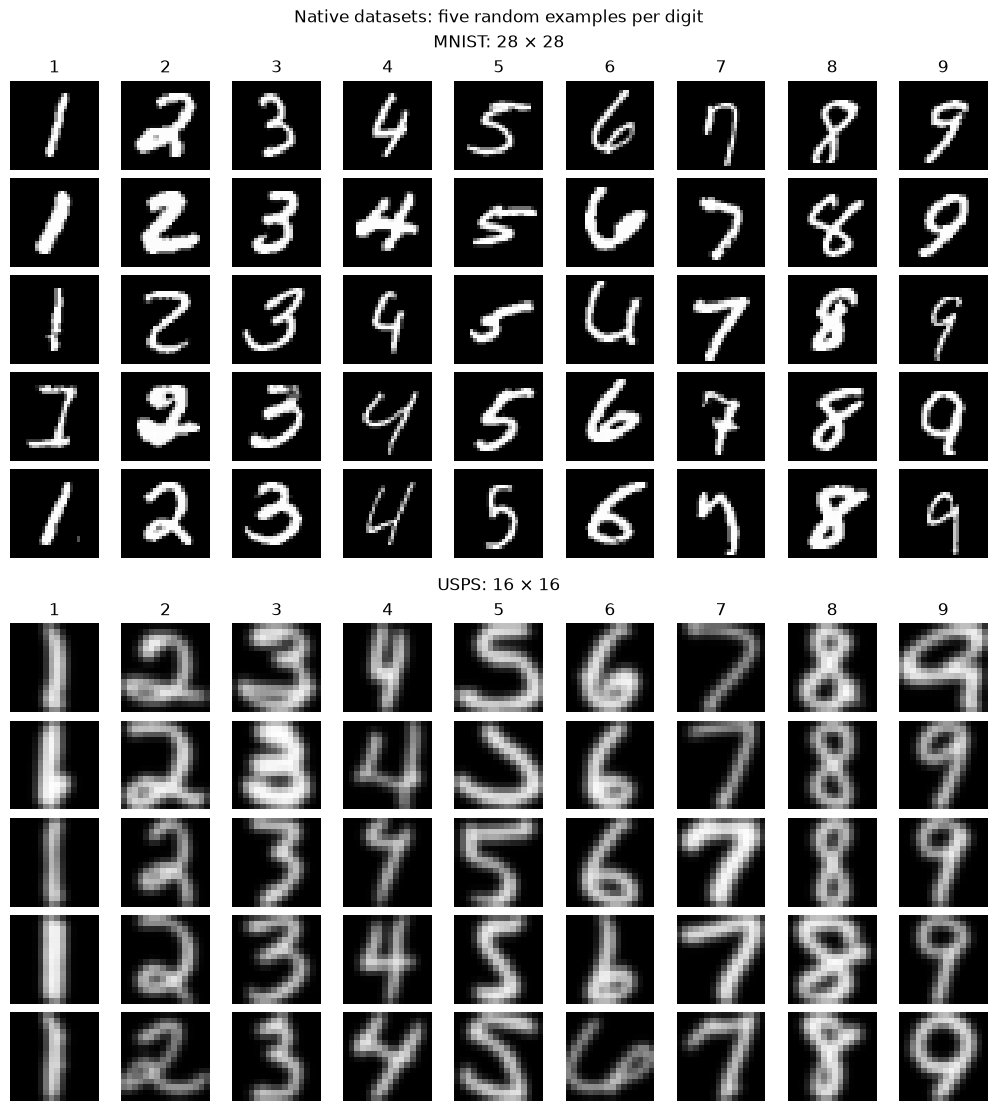

In [33]:
source_train, target_train, native_examples = training_data(DATA_DIR, cfg)
print(f"Training images: MNIST {len(source_train):,}; USPS {len(target_train):,}")
print("Source item: (image, digit index); target item: image only")
plot_inputs(native_examples)
plt.savefig("plots/input_examples.png", dpi=450, bbox_inches="tight")
plt.show()


## 3. How DANN works

The encoder maps each image to two numbers, $z=(z_1,z_2)$. Two small classifiers read this representation:

| Component | Architecture | What it learns |
|---|---|---|
| Encoder | Two convolution + ReLU + pooling blocks, another convolution + ReLU, then FC(64) → FC(2) | A shared representation |
| Digit / health classifier | 2 → 32 → 32 → 9 | Which digit? |
| Domain classifier | 2 → 32 → 32 → 2 | MNIST or USPS? |

**Source-only learning** minimizes digit cross-entropy $L_y$ on labelled MNIST images.

**DANN** also computes domain cross-entropy $L_d$ using images from both datasets. Domain membership is known even when the USPS digit is unknown.

- The digit classifier minimizes $L_y$.
- The domain classifier minimizes $L_d$.
- The encoder minimizes $L_y - \lambda L_d$: keep class information, make domain recognition harder.

A **gradient-reversal layer** leaves the forward values unchanged and multiplies the gradient towards the encoder by $-\lambda$. In `demo.py`, `loss = classification + domain_loss`; gradient reversal supplies the negative sign and scaling. Each domain has equal weight in $L_d$.

Both experiments start from identical weights and use the same MNIST batches and epoch budget. In DANN, adversarial pressure is off for three epochs, then increases linearly to its maximum (`0.1`) at 60% of training and stays constant afterwards. With 30 epochs, the ramp finishes at the end of epoch 18. Changing `EPOCHS` automatically moves this endpoint. The domain classifier still learns during warm-up, but its gradient into the encoder is zero.


In [10]:
model = DANN()
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
del model


DANN(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=1568, out_features=64, bias=True)
    (10): ReLU()
    (11): Linear(in_features=64, out_features=2, bias=True)
  )
  (health_classifier): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=9, bias=True)
  )
  (domain_classifier): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
 

## 4. Source-only learning

Train the encoder and digit classifier using MNIST labels. USPS is not passed to this training call.

We save the final epoch and finish both experiments before revealing test labels. No USPS accuracy is used to select a checkpoint.


In [11]:
source_path = CHECKPOINT_DIR / "source_only_dann_v3.pt"
if MODE == "train":
    source_model, source_history = fit(source_train, None, cfg, adaptation=False, device=DEVICE)
    save_checkpoint(source_path, source_model, source_history, cfg, adaptation=False)
    source_config = asdict(cfg)
else:
    source_model, source_history, source_config = load_checkpoint(source_path, adaptation=False, device=DEVICE)


source-only | epoch 01/30 | digit CE 1.321
source-only | epoch 02/30 | digit CE 0.689
source-only | epoch 03/30 | digit CE 0.420
source-only | epoch 04/30 | digit CE 0.275
source-only | epoch 05/30 | digit CE 0.207
source-only | epoch 06/30 | digit CE 0.166
source-only | epoch 07/30 | digit CE 0.135
source-only | epoch 08/30 | digit CE 0.119
source-only | epoch 09/30 | digit CE 0.104
source-only | epoch 10/30 | digit CE 0.092
source-only | epoch 11/30 | digit CE 0.084
source-only | epoch 12/30 | digit CE 0.078
source-only | epoch 13/30 | digit CE 0.068
source-only | epoch 14/30 | digit CE 0.058
source-only | epoch 15/30 | digit CE 0.055
source-only | epoch 16/30 | digit CE 0.052
source-only | epoch 17/30 | digit CE 0.046
source-only | epoch 18/30 | digit CE 0.045
source-only | epoch 19/30 | digit CE 0.040
source-only | epoch 20/30 | digit CE 0.034
source-only | epoch 21/30 | digit CE 0.033
source-only | epoch 22/30 | digit CE 0.030
source-only | epoch 23/30 | digit CE 0.031
source-only

## 5. Add domain-adversarial learning

The digit classifier still learns only from MNIST labels. The domain classifier sees both MNIST and USPS images, with domain labels 0 and 1. Through gradient reversal, it encourages the encoder to learn features that transfer.


In [12]:
adapted_path = CHECKPOINT_DIR / "adapted_dann_v3.pt"
if MODE == "train":
    adapted_model, adapted_history = fit(source_train, target_train, cfg, adaptation=True, device=DEVICE)
    save_checkpoint(adapted_path, adapted_model, adapted_history, cfg, adaptation=True)
    adapted_config = asdict(cfg)
else:
    adapted_model, adapted_history, adapted_config = load_checkpoint(adapted_path, adaptation=True, device=DEVICE)

if source_config != adapted_config:
    raise ValueError("The checkpoints use different training settings. Use a matched pair for this comparison.")


adapted     | epoch 01/30 | digit CE 1.321 | domain accuracy 63.5%
adapted     | epoch 02/30 | digit CE 0.689 | domain accuracy 72.2%
adapted     | epoch 03/30 | digit CE 0.420 | domain accuracy 82.9%
adapted     | epoch 04/30 | digit CE 0.275 | domain accuracy 86.3%
adapted     | epoch 05/30 | digit CE 0.207 | domain accuracy 85.0%
adapted     | epoch 06/30 | digit CE 0.168 | domain accuracy 82.2%
adapted     | epoch 07/30 | digit CE 0.137 | domain accuracy 79.4%
adapted     | epoch 08/30 | digit CE 0.123 | domain accuracy 74.7%
adapted     | epoch 09/30 | digit CE 0.107 | domain accuracy 70.0%
adapted     | epoch 10/30 | digit CE 0.094 | domain accuracy 67.2%
adapted     | epoch 11/30 | digit CE 0.084 | domain accuracy 65.2%
adapted     | epoch 12/30 | digit CE 0.080 | domain accuracy 64.5%
adapted     | epoch 13/30 | digit CE 0.069 | domain accuracy 62.5%
adapted     | epoch 14/30 | digit CE 0.062 | domain accuracy 62.1%
adapted     | epoch 15/30 | digit CE 0.057 | domain accuracy 6

## 6. Inspect training

Does the digit loss decrease? Does the domain classifier become less able to distinguish the datasets?

Balanced domain accuracy near 50% is consistent with domain confusion, but can also reflect a weak classifier. It does **not** prove that digits align correctly.


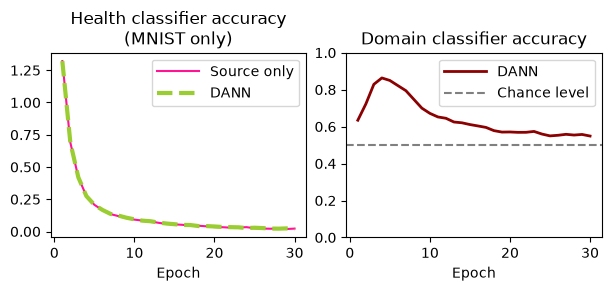

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(6, 2.8), layout="constrained")
for name, history, lw, ls, c in (("Source only", source_history, 1.5, "-", "deeppink"), ("DANN", adapted_history, 3, "--", "yellowgreen")):
    epochs = np.arange(1, len(history) + 1)
    axes[0].plot(epochs, [h["classification"] for h in history], label=name, lw=lw, ls=ls, c=c)
axes[0].set_title("Health classifier accuracy\n(MNIST only)")
axes[1].plot(np.arange(1, len(adapted_history) + 1),
             [h["domain_accuracy"] for h in adapted_history], label="DANN", lw= 2, c='darkred')
axes[1].axhline(0.5, color="gray", linestyle="--", label="Chance level")
axes[1].set_title("Domain classifier accuracy")
axes[1].set_ylim(0, 1)
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend(handlelength=3)
plt.savefig("plots/training_history.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Reveal test labels: source-only results

**Training is finished.** We now use the official test splits to measure accuracy and colour latent-space plots. Neither test images nor test labels were used for training.

Does the source-only classifier perform better on MNIST than USPS? The three panels show domain overlap and the true digits in each domain. These are the actual two latent coordinates, without PCA or t-SNE.


SOURCE ONLY
MNIST: 97.8% accuracy (n=9,020)
USPS: 60.4% accuracy (n=1,648)


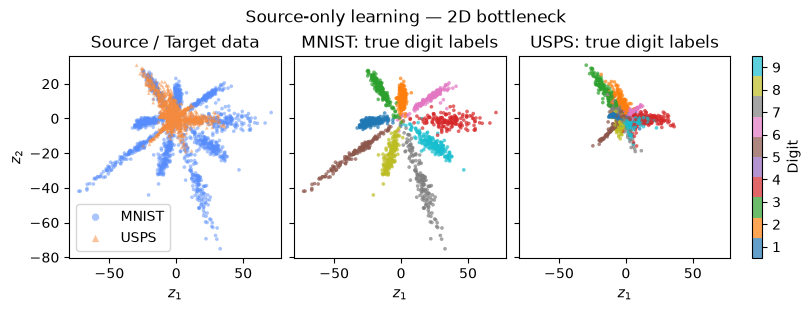

In [31]:
source_test, target_test = test_data(DATA_DIR)
source_results = {
    "MNIST": evaluate(source_model, source_test, DEVICE),
    "USPS": evaluate(source_model, target_test, DEVICE),
}
print("SOURCE ONLY")
for domain, result in source_results.items():
    print(f"{domain}: {result['accuracy']:.1%} accuracy (n={len(result['y']):,})")
plot_latent(source_results["MNIST"], source_results["USPS"], "Source-only learning")
plt.savefig("plots/source_only_latent.png", dpi=300, bbox_inches="tight")
plt.show()


### Did DANN improve transfer?

Compare USPS accuracy before and after adaptation. Then check whether points with the same digit colour align across the two domains. Domain overlap alone is insufficient: different digits can mix incorrectly.

Axes are shared within each figure. Separately trained models can rotate or rescale their latent coordinates, so absolute coordinates need not match between figures.


DANN
MNIST: 97.8% accuracy (n=9,020)
USPS: 82.5% accuracy (n=1,648)


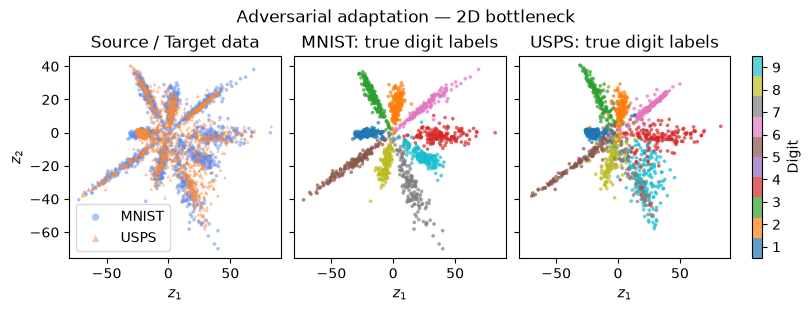

In [28]:
adapted_results = {
    "MNIST": evaluate(adapted_model, source_test, DEVICE),
    "USPS": evaluate(adapted_model, target_test, DEVICE),
}
print("DANN")
for domain, result in adapted_results.items():
    print(f"{domain}: {result['accuracy']:.1%} accuracy (n={len(result['y']):,})")
plot_latent(adapted_results["MNIST"], adapted_results["USPS"], "Adversarial adaptation")
plt.savefig("plots/adapted_latent.png", dpi=300, bbox_inches="tight")
plt.show()


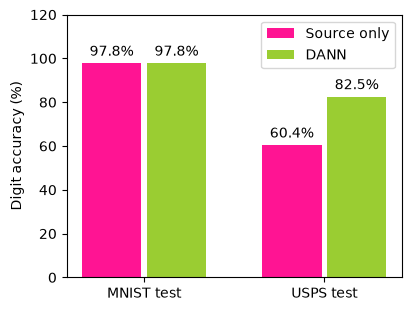

USPS change after adaptation: +22.1 percentage points


In [30]:
fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
x = np.arange(2)
for offset, name, results, c in ((-0.18, "Source only", source_results, "deeppink"), (0.18, "DANN", adapted_results, "yellowgreen")):
    bars = ax.bar(x + offset, [100 * results[d]["accuracy"] for d in ("MNIST", "USPS")],
                  width=0.33, label=name, color=c)
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_xticks(x, ["MNIST test", "USPS test"])
ax.set_ylim(0, 120)
ax.set_ylabel("Digit accuracy (%)")
ax.legend()
plt.savefig("plots/accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
change = 100 * (adapted_results["USPS"]["accuracy"] - source_results["USPS"]["accuracy"])
print(f"USPS change after adaptation: {change:+.1f} percentage points")


### Which digits benefit from adaptation?

Rows are **true digits** and columns are **predictions**. Each row is normalized to 100%, so the diagonal gives the percentage classified correctly for that digit. Off-diagonal entries show which digits are confused. Both panels use the same colour scale.

These matrices use USPS test labels only after training. Does DANN help most digits, or only a few?


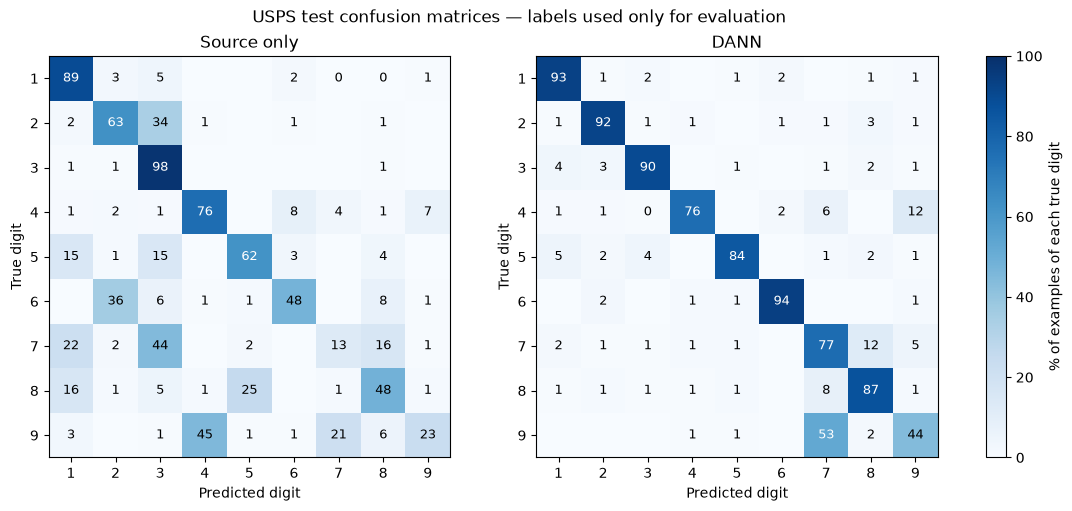

In [32]:
plot_confusion_matrices(source_results["USPS"], adapted_results["USPS"])
plt.savefig("plots/confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Discuss the PBSHM lesson

1. Does DANN improve USPS accuracy while retaining useful MNIST accuracy?
2. Do the latent plots show alignment of the same classes, or merely mixing of domains?
3. For two structures, what differences should a representation ignore, and what health information must it preserve?

A 2D bottleneck makes this visible but limits the model. A large initial accuracy gap and positive transfer are **not guaranteed**; report the measured result. If USPS scores are used to choose settings or seeds, those labels become validation information rather than an untouched final evaluation.

**Reference:** Ganin et al. (2016), [Domain-Adversarial Training of Neural Networks](https://jmlr.org/papers/v17/15-239.html).
Dataset documentation: [MNIST](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html), [USPS](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.USPS.html).

The implementation is in `demo.py`.
